# Hierarchical models with per-group shape parameters

chebax's traced entry points take their parameters as scalars, uniform per
call: `betainc_fn(a, b, x)` wants one `a` and one `b` for the whole array.
That is a deliberate scope boundary (the tables are reconstructed once per
call, not once per element), and it is also the first thing that bites when
you write the model you actually wanted:

```python
with numpyro.plate("groups", G):
    a = numpyro.sample("a", ...)      # one shape PER GROUP
```

`chebax.pergroup` is the middle ground. A static integer array assigns each
element to a group; each group gets its own traceable parameters; one call
covers the whole array, with G table reconstructions instead of N.

The model here is a truncated Beta whose shapes vary by group, fitted with
NUTS. It is the plate version of `chebax.numpyro.TruncatedBeta`, which is
uniform-per-call.

In [1]:
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)

import numpyro
import numpyro.distributions as dist
from numpyro.infer import MCMC, NUTS

import chebax

## The data: six assays, each with its own detection window

Six groups of measurements on (0, 1). Each group has its own Beta shapes.
Each individual observation has its own truncation window `[lo_i, hi_i]`,
which is what an assay with a per-run detection range looks like.

That per-observation window is what makes this a real `pergroup` problem
rather than a loop over six scalars: the truncation mass
`I_hi(a_g, b_g) - I_lo(a_g, b_g)` has to be evaluated at bounds that vary
per observation, with shapes that vary per group.

In [2]:
G, NPER = 6, 150
A_TRUE = np.array([1.5, 2.0, 3.0, 4.0, 6.0, 9.0])
B_TRUE = np.array([2.5, 1.5, 4.0, 2.0, 5.0, 4.0])

rng = np.random.default_rng(0)
gidx = np.repeat(np.arange(G), NPER)          # STATIC: numpy, not traced
n = G * NPER
lo = rng.uniform(0.02, 0.25, n)
hi = np.minimum(lo + rng.uniform(0.45, 0.70, n), 0.99)

y = np.empty(n)                                # draw, keep what lands in window
for i in range(n):
    while True:
        v = rng.beta(A_TRUE[gidx[i]], B_TRUE[gidx[i]])
        if lo[i] < v < hi[i]:
            y[i] = v
            break

lo, hi, y = jnp.asarray(lo), jnp.asarray(hi), jnp.asarray(y)
print(f"{n} observations in {G} groups; windows vary per observation")
print(f"group 0 window example: [{float(lo[0]):.3f}, {float(hi[0]):.3f}]")

900 observations in 6 groups; windows vary per observation
group 0 window example: [0.167, 0.852]


## Wiring `pergroup`

One call builds the wrapper. `group_idx` is numpy and static: the index
bookkeeping (sort, counts, offsets) is done once here, not per step. Rebuild
the wrapper if the grouping changes.

The wrapped function has the same signature as `betainc_fn`, except each
parameter is now a length-G array.

In [3]:
cdf = chebax.pergroup(chebax.betainc_fn, gidx, num_groups=G)

a_demo = jnp.array([1.5, 2.0, 3.0, 4.0, 6.0, 9.0])
b_demo = jnp.array([2.5, 1.5, 4.0, 2.0, 5.0, 4.0])
print("one call, per-group shapes:", np.asarray(cdf(a_demo, b_demo, y))[:4])

# elementwise reference: what the loop would have given
ref = np.array([float(chebax.betainc_fn(a_demo[gidx[i]], b_demo[gidx[i]], y[i]))
                for i in range(4)])
print("elementwise reference:     ", ref)

one call, per-group shapes: [0.7646402  0.77178367 0.31279607 0.23121862]


elementwise reference:      [0.7646402  0.77178367 0.31279607 0.23121862]


Gradients reach every group's parameters, and a group's gradient depends
only on its own elements.

In [4]:
ga, gb = jax.grad(lambda a, b: jnp.sum(cdf(a, b, y)), (0, 1))(a_demo, b_demo)
print("dI/da per group:", np.round(np.asarray(ga), 3))
print("dI/db per group:", np.round(np.asarray(gb), 3))

dI/da per group: [-35.561 -26.062 -23.092 -13.831 -12.763  -7.989]
dI/db per group: [20.4   31.693 16.23  24.648 15.05  16.418]


## The model

Shapes are drawn per group from a shared hyperprior, so the groups pool
partially rather than being fitted independently. The likelihood is the
untruncated Beta density divided by the mass inside each observation's
window, which is where `pergroup` earns its place.

One more wiring point. The likelihood needs the CDF at TWO bounds. Written
the obvious way, `cdf(a, b, hi) - cdf(a, b, lo)`, the traced graph carries
two independent sets of per-group table reconstructions. Stacking the bounds
into one array (with the group index stacked to match) leaves one set: a
smaller graph to trace, compile and differentiate.

It does not make the run cheap. Sampling dominates this model, not
compilation: on one CPU core-set here, tracing and compiling cost tens of
seconds and the 400 draws cost several minutes.

In [5]:
gidx2 = np.concatenate([gidx, gidx])          # still static
bounds = jnp.concatenate([lo, hi])
cdf2 = chebax.pergroup(chebax.betainc_fn, gidx2, num_groups=G)

In [6]:
def model(lo, hi, y=None):
    mu_la = numpyro.sample("mu_log_a", dist.Normal(0.5, 1.0))
    mu_lb = numpyro.sample("mu_log_b", dist.Normal(0.5, 1.0))
    tau = numpyro.sample("tau", dist.HalfNormal(1.0))
    with numpyro.plate("groups", G):
        log_a = numpyro.sample("log_a", dist.Normal(mu_la, tau))
        log_b = numpyro.sample("log_b", dist.Normal(mu_lb, tau))
    # clipped to the table box [0.1, 100]; the prior keeps us far inside it
    a = jnp.clip(jnp.exp(log_a), 0.11, 99.0)
    b = jnp.clip(jnp.exp(log_b), 0.11, 99.0)

    base = dist.Beta(a[gidx], b[gidx]).log_prob(y)
    both = cdf2(a, b, bounds)                  # one call covers both bounds
    mass = both[n:] - both[:n]
    numpyro.factor("obs", jnp.sum(base - jnp.log(jnp.clip(mass, 1e-12, 1.0))))


mcmc = MCMC(NUTS(model), num_warmup=200, num_samples=200, num_chains=1,
            progress_bar=False)
mcmc.run(jax.random.PRNGKey(0), lo, hi, y=y)

# with progress_bar=False the whole chain is one lax.scan and mcmc.run
# returns before it has run: the work happens when the samples are touched.
# Time a numpyro model around get_samples(), not around run(), or you are
# timing the dispatch and concluding the model is fast.
post = mcmc.get_samples()
a_post = np.exp(np.asarray(post["log_a"]))
b_post = np.exp(np.asarray(post["log_b"]))
print(f"{a_post.shape[0]} draws, {G} groups")

200 draws, 6 groups


## Did it recover the shapes?

In [7]:
print(f"{'group':>6} {'a_true':>8} {'a_med':>8} {'90% CI':>16} "
      f"{'b_true':>8} {'b_med':>8} {'90% CI':>16}")
for g in range(G):
    aq = np.percentile(a_post[:, g], [5, 50, 95])
    bq = np.percentile(b_post[:, g], [5, 50, 95])
    print(f"{g:6d} {A_TRUE[g]:8.2f} {aq[1]:8.2f} "
          f"[{aq[0]:6.2f},{aq[2]:6.2f}] {B_TRUE[g]:8.2f} {bq[1]:8.2f} "
          f"[{bq[0]:6.2f},{bq[2]:6.2f}]")

 group   a_true    a_med           90% CI   b_true    b_med           90% CI
     0     1.50     1.27 [  0.73,  1.93]     2.50     2.13 [  1.27,  3.06]
     1     2.00     1.86 [  1.35,  2.61]     1.50     1.23 [  0.66,  2.07]
     2     3.00     3.40 [  2.51,  4.48]     4.00     5.10 [  3.38,  6.85]
     3     4.00     3.86 [  2.94,  4.61]     2.00     1.92 [  1.13,  2.75]
     4     6.00     4.92 [  3.79,  6.15]     5.00     3.29 [  2.26,  4.67]
     5     9.00     7.67 [  5.72,  9.78]     4.00     2.90 [  1.66,  4.44]


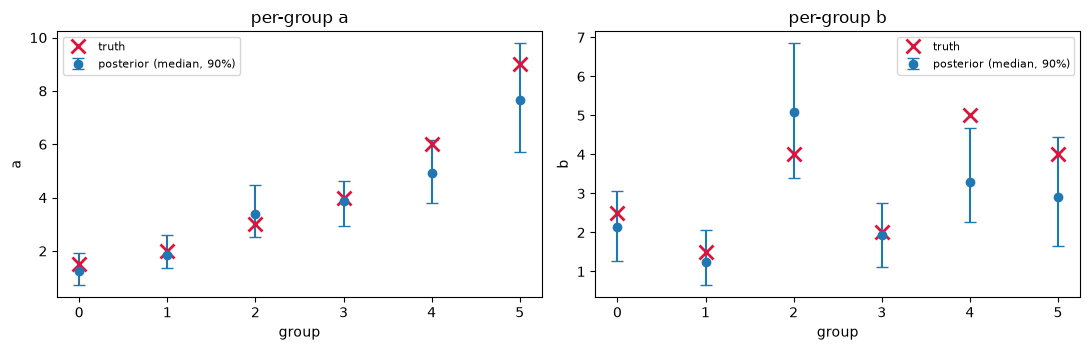

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
for ax, post_g, true_g, name in ((axes[0], a_post, A_TRUE, "a"),
                                 (axes[1], b_post, B_TRUE, "b")):
    med = np.percentile(post_g, 50, axis=0)
    lo_ci = med - np.percentile(post_g, 5, axis=0)
    hi_ci = np.percentile(post_g, 95, axis=0) - med
    ax.errorbar(np.arange(G), med, yerr=[lo_ci, hi_ci], fmt="o",
                capsize=4, label="posterior (median, 90%)")
    ax.plot(np.arange(G), true_g, "x", ms=10, mew=2, color="crimson",
            label="truth")
    ax.set_xlabel("group")
    ax.set_ylabel(name)
    ax.set_title(f"per-group {name}")
    ax.legend(fontsize=8)
fig.tight_layout()

Each group gets its own shapes and its own uncertainty, from one NUTS run
over a single array. Nothing here loops over groups in python.

Expect about one of the twelve intervals to miss. These are 90% intervals
over 12 parameters, so all twelve covering would be the surprising outcome,
not the reassuring one.

## What it costs, and when to reach for it

`pergroup` reconstructs G parameter-dependent table slices per call instead
of one, so it is worth it when each group has enough elements to pay for its
own reconstruction. `experiments/07` measures the crossover: reconstruction
overhead stays within 1.07x of the uniform floor once a group holds about
16k elements (betainc), and besselk stays within 1.08x down to 1024. Against
jax's own betainc the per-group path wins every measured cell, by 44-98x at
MCMC scale.

Below that, with tiny groups, the uniform path called in a python loop is
the honest alternative; `pergroup` is not magic, it is a batching strategy
with a break-even point.

Three things worth knowing:

- `group_idx` is static. It is numpy, it is not traced, and changing the
  grouping means building a new wrapper. This is what lets the index work
  happen once instead of per step.
- An empty group is inert. Its parameters never reach the wrapped function,
  so a nan parked in an empty slot changes no value and no gradient, and its
  own gradient is exactly zero.
- The domain box still applies per group: every group's parameters must sit
  inside the family's table box ([0.1, 100] for betainc). The model clips to
  it, and the hyperprior keeps the draws far inside.

## Where the shape parameter should live

One caveat that is about statistics rather than about chebax. A per-group
parameter is only recoverable if the data speak to it. Beta shapes are
recovered well here because the observations are draws from the Beta itself.
A tail-weight parameter buried in a link function (the `df` of a robit
regression, say) is far more weakly identified, and a hierarchical prior will
shrink it hard. That is a property of the model, not of the machinery: the
gradients flow either way.

Related: `notebooks/03` for the uniform-per-call truncated distributions,
`notebooks/07` for censoring and robust likelihoods in a single group.